# **Подготовка данных и Dataset**

In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
!pip install yfinance

import yfinance as yf

# Скачиваем данные Лукойла (тикер LKOH.ME для Мосбиржи)
# Период 'max' или конкретные даты, например с 2010 года
data_yf = yf.download('LKOH.ME', start='2010-01-01')

# Extract only the 'Close' price for 'LKOH.ME' and rename the column to 'CLOSE'
# The yf.download output 'data_yf' has multi-level columns like ('Close', 'LKOH.ME')
close_prices = data_yf[('Close', 'LKOH.ME')]

# Convert to a DataFrame with a single column named 'CLOSE'
data_to_save = close_prices.to_frame(name='Close')

# Сохраняем только цену 'CLOSE' в 1luk.csv
data_to_save.to_csv('1luk.csv')
# Загрузка и очистка
df = pd.read_csv('1luk.csv', sep=',')
df = df.dropna().reset_index(drop=True)
data = df['Close'].values.reshape(-1, 1)

# Масштабирование
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data).astype(np.float32)

# Класс для создания окон
class StockDataset(Dataset):
    def __init__(self, data, lookback, forecast=1):
        self.data = data
        self.lookback = lookback
        self.forecast = forecast

    def __len__(self):
        return len(self.data) - self.lookback - self.forecast + 1

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.lookback]
        y = self.data[idx + self.lookback : idx + self.lookback + self.forecast]
        return torch.from_numpy(x), torch.from_numpy(y).flatten()

# Параметры
win_len = 30
train_size = int(len(data_scaled) * 0.8)

train_ds = StockDataset(data_scaled[:train_size], win_len)
test_ds = StockDataset(data_scaled[train_size:], win_len)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

/tmp/ipykernel_5020/2340531311.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_yf = yf.download('LKOH.ME', start='2010-01-01')
[*********************100%***********************]  1 of 1 completed


# **Модель и обучение**

In [5]:
class StockPredictor(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.linear1(x))
        return self.linear2(x)

# Инициализация
model = StockPredictor(win_len, 64, 1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Цикл обучения
model.train()
for epoch in range(20):
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(x_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
    if (epoch+1) % 5 == 0:
        print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')

Epoch 5, Loss: 0.0043
Epoch 10, Loss: 0.0005
Epoch 15, Loss: 0.0003
Epoch 20, Loss: 0.0006


# **Прогноз на 10 шагов**

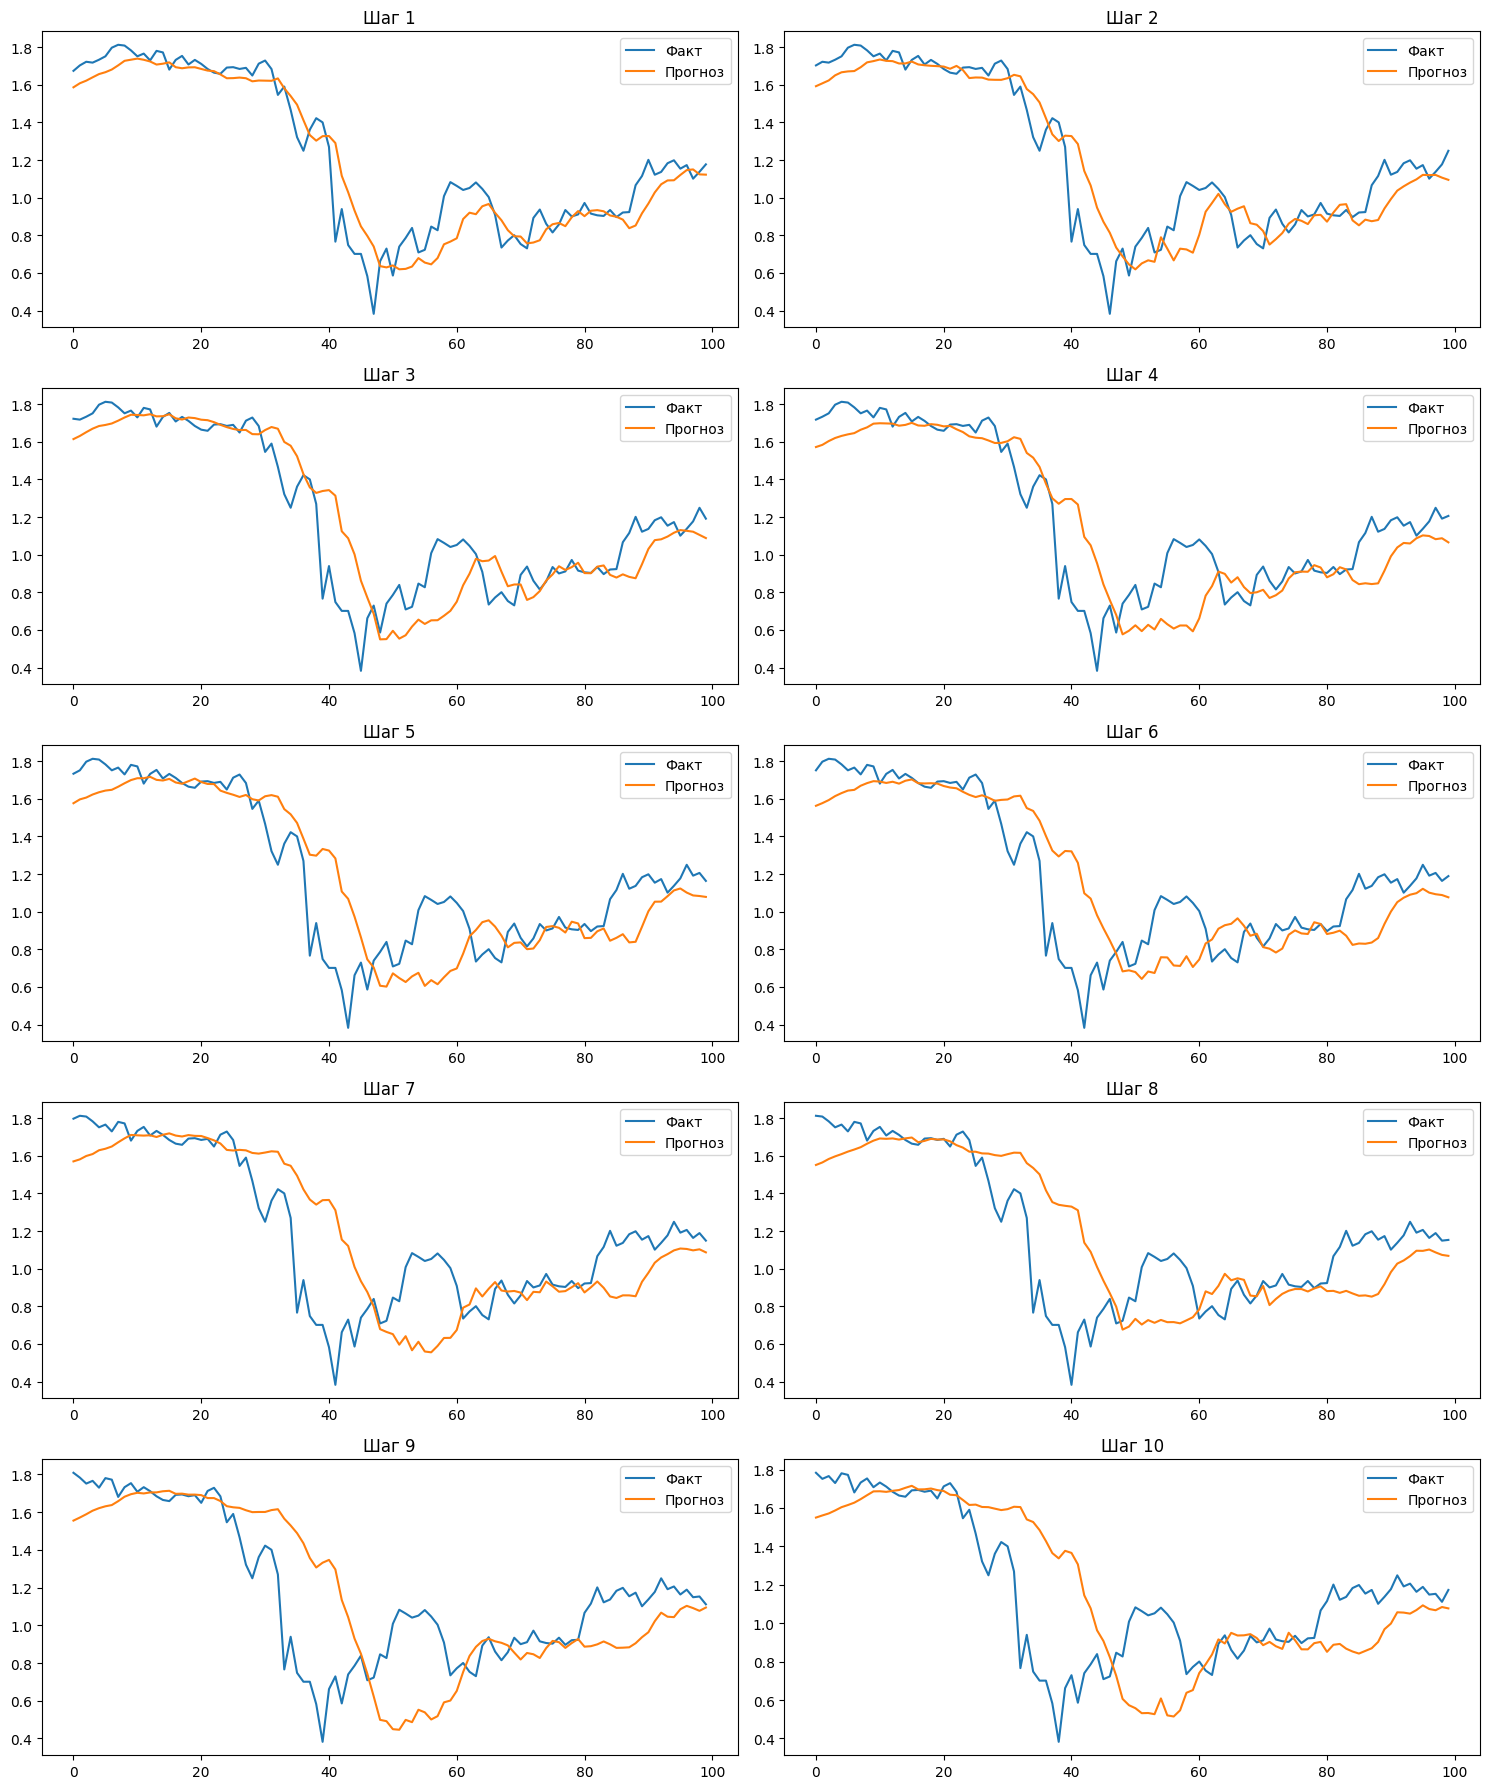

In [6]:
# Пересобираем датасет для 10 шагов
future_steps = 10
train_ds_10 = StockDataset(data_scaled[:train_size], win_len, forecast=future_steps)
test_ds_10 = StockDataset(data_scaled[train_size:], win_len, forecast=future_steps)
train_loader_10 = DataLoader(train_ds_10, batch_size=32, shuffle=True)

# Модель на 10 выходов
model_10 = StockPredictor(win_len, 128, future_steps)
optimizer_10 = torch.optim.Adam(model_10.parameters(), lr=0.001)

# Обучение (аналогично блоку выше)
model_10.train()
for epoch in range(30):
    for x_batch, y_batch in train_loader_10:
        optimizer_10.zero_grad()
        out = model_10(x_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer_10.step()

# Визуализация 10 шагов (Задание 3)
model_10.eval()
with torch.no_grad():
    x_test_all = []
    y_true_all = []
    y_pred_all = []
    for x, y in DataLoader(test_ds_10, batch_size=1):
        pred = model_10(x)
        y_true_all.append(y.numpy())
        y_pred_all.append(pred.numpy())

y_true_all = np.array(y_true_all).squeeze()
y_pred_all = np.array(y_pred_all).squeeze()

# Рисуем первые 100 точек для каждого из 10 шагов
fig, axes = plt.subplots(5, 2, figsize=(15, 18))
axes = axes.flatten()
for i in range(10):
    axes[i].plot(y_true_all[:100, i], label='Факт')
    axes[i].plot(y_pred_all[:100, i], label='Прогноз')
    axes[i].set_title(f'Шаг {i+1}')
    axes[i].legend()
plt.tight_layout()
plt.show()

# **Продвинутая модель (LSTM)**

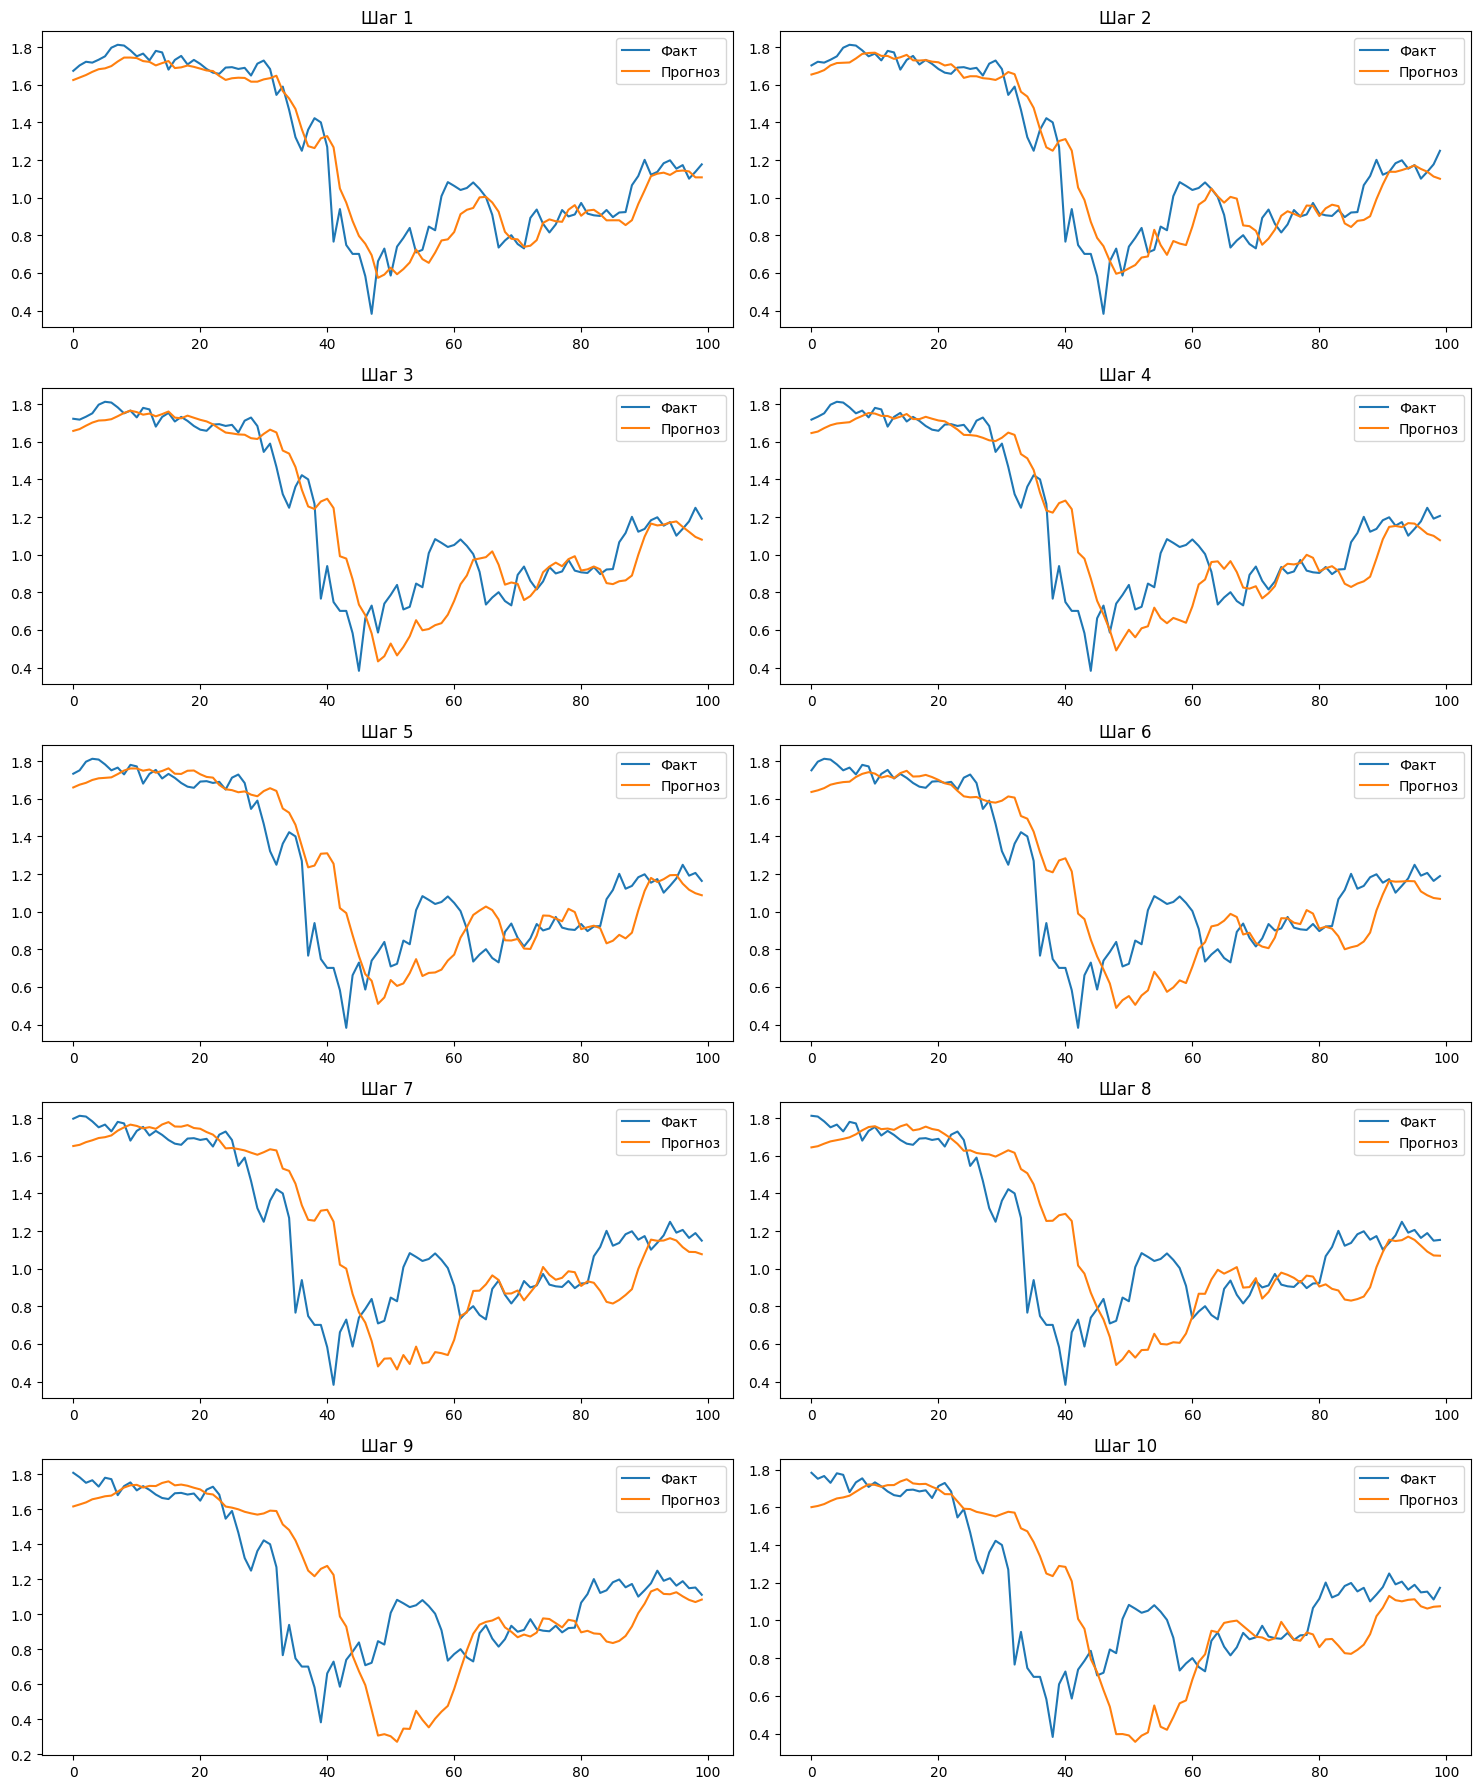

In [8]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape: (batch, seq_len, features)
        out, _ = self.lstm(x)
        # берем только последний выход последовательности
        out = self.fc(out[:, -1, :])
        return out

model_lstm = LSTMModel(input_size=1, hidden_size=50, num_layers=2, output_size=1)
# Обучение проводится по той же схеме, что и для Dense

# Обучение (аналогично блоку выше)
model_10.train()
for epoch in range(30):
    for x_batch, y_batch in train_loader_10:
        optimizer_10.zero_grad()
        out = model_10(x_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer_10.step()

# Визуализация 10 шагов (Задание 3)
model_10.eval()
with torch.no_grad():
    x_test_all = []
    y_true_all = []
    y_pred_all = []
    for x, y in DataLoader(test_ds_10, batch_size=1):
        pred = model_10(x)
        y_true_all.append(y.numpy())
        y_pred_all.append(pred.numpy())

y_true_all = np.array(y_true_all).squeeze()
y_pred_all = np.array(y_pred_all).squeeze()

# Рисуем первые 100 точек для каждого из 10 шагов
fig, axes = plt.subplots(5, 2, figsize=(15, 18))
axes = axes.flatten()
for i in range(10):
    axes[i].plot(y_true_all[:100, i], label='Факт')
    axes[i].plot(y_pred_all[:100, i], label='Прогноз')
    axes[i].set_title(f'Шаг {i+1}')
    axes[i].legend()
plt.tight_layout()
plt.show()